# Validación de Sensor MOx con Captura Real — MQ-136 + BME280 (ESP32-S3)
### UKF 1D (log-space) + Regresión Polinomial | Marco teórico: Bârsan-Langmuir

**Pipeline:** `ohm → limpieza física → mediana (W) → R_k → {despeje analítico, UKF} → PoliReg → métricas`

Esta captura corresponde a una sesión de **aire limpio** (sin fuente de gas objetivo), por lo que
`C_target` es constante (`C0 = 0.01 ppm`) durante toda la simulación. Esto no valida la respuesta
del sistema ante un evento de gas real, pero sí permite caracterizar rigurosamente el **rechazo de
ruido** del pipeline — un requisito previo indispensable antes de validar contra gas real.

## 1. Librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model  import LinearRegression
from sklearn.metrics       import mean_squared_error, mean_absolute_error, r2_score

np.random.seed(42)

plt.rcParams.update({
    'figure.dpi':        120,
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.size':         10
})

## 2. Configuración

Todos los parámetros viven en diccionarios explícitos. Ninguna función los lee como variable global — siempre se pasan por argumento.

In [2]:
# ── Parámetros del sensor MOx (Bârsan-Langmuir) ──────────────────────────────
PARAMS = {
    'K_base': 0.06,      # Factor pre-exponencial [Ω·ppm^n]
    'n':      0.5,       # Exponente de la ley de potencias del gas reductor
    'Ea':     0.3,       # Energía de activación [eV]
    'kB':     8.617e-5,  # Constante de Boltzmann [eV/K]
    'Kw':     0.02,      # Afinidad de adsorción de agua
    'gamma':  0.5,       # Exponente de la isoterma de Langmuir
}

# ── Configuración del UKF (Transformada Unscented) ───────────────────────────
UKF_CFG = {
    'C0':    0.01,   # Concentración inicial: aire limpio sin gas [ppm] — ec. (36)
    'P0':    1.0,    # Covarianza inicial
    'alpha': 0.001,  # Dispersión de puntos sigma — pequeña para evitar
                     # evaluar concentraciones físicamente imposibles
    'beta':  2.0,    # Conocimiento previo de la distribución del ruido
}

# ── Límites físicos válidos para T y RH (rechazo de outliers de hardware) ────
ENV_LIMITS = {
    'T_MIN':  0.0,   # °C
    'T_MAX':  50.0,  # °C
    'RH_MIN': 0.0,   # %
    'RH_MAX': 99.0,  # %
}

W = 11                     # Ventana del filtro de mediana (impar, causal)
TRANSIENT_CUTOFF = 500     # Muestras rechazadas al inicio (calentamiento del sensor)
CSV_PATH = 'captura_MQ136_BME280.csv'
KELVIN_OFFSET = 273.15

## 3. Funciones

### 3.1 Carga y limpieza de datos

Rechaza valores físicamente imposibles de T/RH (fallas eléctricas del BME280), los interpola linealmente, y descarta el transitorio inicial de calentamiento del sensor.

In [3]:
def load_and_clean_data(path: str, limits: dict, cutoff: int) -> pd.DataFrame:
    """
    Carga la captura real y aplica dos etapas de limpieza:
      1. Filtro de umbral físico en T y RH — valores fuera de rango se marcan NaN
         y se interpolan linealmente (fallas eléctricas puntuales del BME280).
      2. Rechazo del transitorio de calentamiento (primeras `cutoff` muestras).

    Espera columnas: 'ohm' (Rs crudo), 'temp' (°C), 'hum' (%RH).
    """
    df = pd.read_csv(path, sep=',', decimal='.', index_col=0)

    fuera_de_rango_T  = (df['temp'] < limits['T_MIN'])  | (df['temp'] > limits['T_MAX'])
    fuera_de_rango_RH = (df['hum']  < limits['RH_MIN']) | (df['hum']  > limits['RH_MAX'])
    df.loc[fuera_de_rango_T,  'temp'] = np.nan
    df.loc[fuera_de_rango_RH, 'hum']  = np.nan

    # limit_direction='both' cubre el caso de un NaN en el primer o último registro
    df['temp'] = df['temp'].interpolate(method='linear', limit_direction='both')
    df['hum']  = df['hum'].interpolate(method='linear', limit_direction='both')

    return df.iloc[cutoff:].reset_index(drop=True)

### 3.2 Filtro de mediana móvil

In [ ]:
def apply_median_filter(signal: np.ndarray, window: int) -> np.ndarray:
    """
    Filtro de mediana causal (min_periods=1) — nunca mira muestras futuras.
    Replica el búfer circular del firmware.
    """
    return (
        pd.Series(signal)
        .rolling(window=window, center=False, min_periods=1)
        .median()
        .to_numpy()
    )

### 3.3 Modelo fenomenológico (Bârsan-Langmuir) — directo e inverso

In [5]:
def modelo_Rs(C: np.ndarray, T_k: np.ndarray, RH: np.ndarray, params: dict) -> np.ndarray:
    """
    Modelo directo — ec. (6) del marco teórico.
    Rs = K_base · C^-n · exp(Ea / kB·T) · (1 + Kw·RH)^-gamma
    """
    C_safe = np.maximum(C, 1e-5)
    termino_termico  = np.exp(params['Ea'] / (params['kB'] * T_k))
    termino_humedad  = (1 + params['Kw'] * RH) ** (-params['gamma'])
    return params['K_base'] * C_safe ** (-params['n']) * termino_termico * termino_humedad


def despeje_analitico(Rs: np.ndarray, T_k: np.ndarray, RH: np.ndarray, params: dict) -> np.ndarray:
    """
    Inversión algebraica del modelo — despeja C a partir de Rs, T y RH.
    C = (Rs / factor_TH)^(-1/n)  donde  factor_TH = K_base · exp(Ea/kBT) · (1+Kw·RH)^-gamma

    El paréntesis sobre la división completa es crítico: sin él, Python aplica
    la potencia solo al denominador.
    """
    Rs_safe = np.maximum(Rs, 1e-5)  # evita log(0) / potencias inestables
    termino_termico = np.exp(params['Ea'] / (params['kB'] * T_k))
    termino_humedad = (1 + params['Kw'] * RH) ** (-params['gamma'])
    factor_TH = params['K_base'] * termino_termico * termino_humedad
    return (Rs_safe / factor_TH) ** (-1.0 / params['n'])

### 3.4 Ruido de medición (N)

Se calculan tres variantes con fines de diagnóstico, pero solo `N_log` alimenta al UKF —
debe compartir escala con el estado `x = log(C)` y la medición `z = log(Rs)`.

In [6]:
def calcular_ruido_medicion(Rs_crudo: np.ndarray, Rs_filtrado: np.ndarray) -> dict:
    """
    Tres estimaciones del ruido de medición, para contexto comparativo:
      - N_lineal   : Var(Rs) en espacio lineal [Ω²] — referencia, no usada por el UKF.
      - N_log      : Var(log(Rs)) — la que realmente alimenta al UKF (misma escala que el estado).
      - N_residual : Var(Rs_crudo - Rs_filtrado) — energía de ruido de alta frecuencia
                     que el filtro de mediana efectivamente removió.
    """
    return {
        'N_lineal':   float(np.var(Rs_crudo)),
        'N_log':      float(np.var(np.log(Rs_crudo))),
        'N_residual': float(np.var(Rs_crudo - Rs_filtrado)),
    }

### 3.5 Pesos estáticos del UKF (L=1)

In [7]:
def calcular_pesos_ukf(alpha: float, beta: float) -> tuple:
    """
    Pesos del UKF unidimensional — ecuaciones (37)-(39) del marco teórico.
    Se calculan una sola vez antes del bucle principal.
    """
    Wm0 = (3*alpha**2 - 1) / (3*alpha**2)          # peso de la media, punto central
    Wc0 = Wm0 + (1 - alpha**2 + beta)               # peso de la covarianza, punto central
    Wmi = 1.0 / (6*alpha**2)                        # puntos laterales (igual para Wm y Wc)
    return Wm0, Wc0, Wmi

### 3.6 UKF 1D en espacio logarítmico

Estado `x = log(C)`, medición `z = log(R_k)` — evita que la ganancia de Kalman colapse
por incompatibilidad de escala entre ppm y Ohms.

**Corrección numérica:** `P = P_pred - K²·Pzz` es la actualización correcta para la
formulación por puntos sigma del UKF (no existe una matriz `H` explícita que permita usar
la forma de Joseph clásica — esa forma asume linealización, lo cual el UKF evita por
diseño). Se mantiene un clamp `P = max(P, eps)` como salvaguarda ante errores de redondeo,
sin alterar la ecuación estructural del filtro.

In [8]:
def correr_ukf(R_k: np.ndarray, T_k: np.ndarray, RH_k: np.ndarray,
               Q_val: float, N_val: float, cfg: dict, params: dict) -> tuple:
    """
    Bucle principal del UKF 1D — ec. (20)-(34) del marco teórico.
    Devuelve (C_ukf, y_tilde): estimación de concentración e innovación (diagnóstico).
    """
    Wm0, Wc0, Wmi = calcular_pesos_ukf(cfg['alpha'], cfg['beta'])
    alpha = cfg['alpha']

    x_est = np.log(cfg['C0'])
    P_est = cfg['P0']

    n_muestras = len(R_k)
    C_ukf   = np.zeros(n_muestras)
    y_tilde = np.zeros(n_muestras)
    log_Rk  = np.log(np.maximum(R_k, 1e-5))

    for k in range(n_muestras):
        # ── Etapa 1: Puntos sigma en log(C) ────────────────────────────────
        spread = np.sqrt(3 * alpha**2 * P_est)
        chi_0, chi_1, chi_2 = x_est, x_est + spread, x_est - spread

        # ── Etapa 2: Predicción — random walk en log-space ─────────────────
        x_pred = Wm0*chi_0 + Wmi*chi_1 + Wmi*chi_2
        P_pred = Wc0*(chi_0-x_pred)**2 + Wmi*(chi_1-x_pred)**2 + Wmi*(chi_2-x_pred)**2 + Q_val

        # ── Etapa 3: Proyección sigma → log(Rs) ─────────────────────────────
        Tk_i, RHk_i = T_k[k], RH_k[k]
        Z0 = np.log(modelo_Rs(np.exp(chi_0), Tk_i, RHk_i, params))
        Z1 = np.log(modelo_Rs(np.exp(chi_1), Tk_i, RHk_i, params))
        Z2 = np.log(modelo_Rs(np.exp(chi_2), Tk_i, RHk_i, params))
        Z_pred = Wm0*Z0 + Wmi*Z1 + Wmi*Z2

        # ── Etapa 4: Actualización ──────────────────────────────────────────
        Pzz = Wc0*(Z0-Z_pred)**2 + Wmi*(Z1-Z_pred)**2 + Wmi*(Z2-Z_pred)**2 + N_val
        Pxz = Wc0*(chi_0-x_pred)*(Z0-Z_pred) + Wmi*(chi_1-x_pred)*(Z1-Z_pred) + Wmi*(chi_2-x_pred)*(Z2-Z_pred)
        K_g = Pxz / Pzz

        innov = log_Rk[k] - Z_pred
        x_est = x_pred + K_g * innov

        P_est = P_pred - K_g**2 * Pzz
        P_est = max(P_est, 1e-9)  # salvaguarda ante errores de redondeo

        C_ukf[k]   = np.exp(x_est)
        y_tilde[k] = innov

    return C_ukf, y_tilde

### 3.7 Regresión polinomial (ec. 35)

**Nota de interpretación:** en una captura de aire limpio, `C_target` es constante — no hay
variación real de concentración que la regresión pueda explicar mediante el término `C_ukf`.
Aplicada aquí, esta regresión no calibra la respuesta a gas real; sirve como diagnóstico de
**rechazo de deriva ambiental**: cuánto de la desviación residual respecto a 0.01 ppm puede
explicarse (y por tanto corregirse) a partir de T y RH. Un R² bajo en este contexto es
información válida, no necesariamente una falla del modelo.

In [9]:
def ajustar_polireg(C_entrada: np.ndarray, T: np.ndarray, RH: np.ndarray, C_target: np.ndarray) -> tuple:
    """
    Regresión polinomial multivariable de grado 2 — ec. (35) del marco teórico.
    Features: [C, T, RH, C², C·T, C·RH, T², T·RH, RH²]
    Devuelve (C_final, modelo, poly) — modelo y poly permiten exportar coeficientes al firmware.
    """
    X = np.column_stack((C_entrada, T, RH))
    poly   = PolynomialFeatures(degree=2, include_bias=False)
    X_poly = poly.fit_transform(X)
    modelo = LinearRegression().fit(X_poly, C_target)
    C_final = modelo.predict(X_poly)
    return C_final, modelo, poly

### 3.8 Métricas

In [26]:
def rmse(estimado: np.ndarray, objetivo: np.ndarray) -> float:
    return float(np.sqrt(np.mean((estimado - objetivo) ** 2)))


def tabla_metricas(resultados: dict, C_target: np.ndarray) -> None:
    """Imprime RMSE, MAE y R² para cada método frente al objetivo (aire limpio constante)."""
    print(f"{'Método':35s}  {'RMSE [ppm]':>12s}  {'MAE [ppm]':>12s}  {'R²':>8s}")
    print("-" * 75)
    for nombre, est in resultados.items():
        print(f"{nombre:35s}  {rmse(est, C_target):6f}  "
              f"{mean_absolute_error(C_target, est):6f}  "
              f"{r2_score(C_target, est):6f}")

## 4. Verificación de implementación (sanity check)

Antes de cargar datos reales, se confirma que la implementación reproduce exactamente la
traza manual del marco teórico (ecuaciones 42-44 y 37-39) para el primer ciclo. Esto no
depende del dataset — es una prueba unitaria pura de la matemática.

In [11]:
spread_test = np.sqrt(3 * 0.001**2 * 1.0)
chi_0_test, chi_1_test, chi_2_test = 0.01, 0.01 + spread_test, 0.01 - spread_test

print("Puntos sigma (ec. 42-44):")
print(f"  chi_0 = {chi_0_test:.6f}   (esperado: 0.010000)")
print(f"  chi_1 = {chi_1_test:.6f}   (esperado: 0.011732)")
print(f"  chi_2 = {chi_2_test:.6f}   (esperado: 0.008268)")
assert abs(chi_1_test - 0.011732) < 1e-5
assert abs(chi_2_test - 0.008268) < 1e-5

Wm0_t, Wc0_t, Wmi_t = calcular_pesos_ukf(0.001, 2.0)
print(f"\nPesos (ec. 37-39):")
print(f"  Wm0 = {Wm0_t:,.2f}   (esperado: ≈ -333332.33)")
print(f"  Wc0 = {Wc0_t:,.2f}   (esperado: ≈ -333329.33)")
print(f"  Wmi = {Wmi_t:,.2f}   (esperado: ≈  166666.66)")
assert abs(Wm0_t - (-333332.33)) < 1.0

print("\n✓ Implementación verificada contra el marco teórico.")

Puntos sigma (ec. 42-44):
  chi_0 = 0.010000   (esperado: 0.010000)
  chi_1 = 0.011732   (esperado: 0.011732)
  chi_2 = 0.008268   (esperado: 0.008268)

Pesos (ec. 37-39):
  Wm0 = -333,332.33   (esperado: ≈ -333332.33)
  Wc0 = -333,329.33   (esperado: ≈ -333329.33)
  Wmi = 166,666.67   (esperado: ≈  166666.66)

✓ Implementación verificada contra el marco teórico.


## 5. Carga de datos reales

In [13]:
df = load_and_clean_data(CSV_PATH, ENV_LIMITS, TRANSIENT_CUTOFF)

Rs = df['ohm'].to_numpy()
T  = df['temp'].to_numpy() + KELVIN_OFFSET   # Kelvin — requerido por el término de Arrhenius
RH = df['hum'].to_numpy()

t = np.arange(len(Rs))  # 1 muestra ≈ 1 segundo (loop delay del firmware)

print(f"Muestras cargadas tras limpieza y transitorio: {len(Rs)}")
print(f"Rs : {Rs.min():.1f} – {Rs.max():.1f} Ω")
print(f"T  : {(T).min():.1f} – {(T).max():.1f} K")
print(f"RH : {RH.min():.1f} – {RH.max():.1f} %RH")

Muestras cargadas tras limpieza y transitorio: 1382
Rs : 14515.6 – 15747.2 Ω
T  : 294.8 – 295.3 K
RH : 71.5 – 79.5 %RH


## 6. Filtro de mediana movil (W=11)

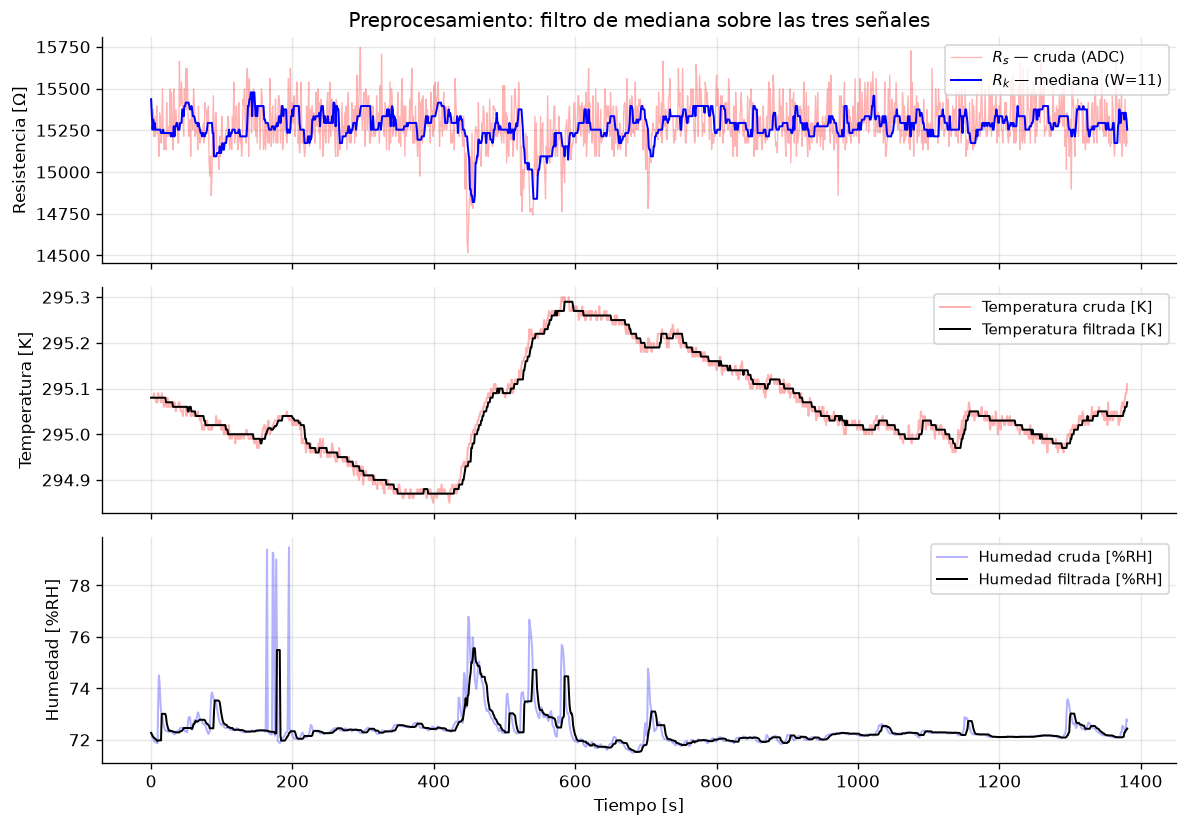

In [14]:
Rk  = apply_median_filter(Rs, W)
Tk  = apply_median_filter(T,  W)
RHk = apply_median_filter(RH, W)

fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)

axes[0].plot(t, Rs, color='red',  alpha=0.3, linewidth=0.8, label='$R_s$ — cruda (ADC)')
axes[0].plot(t, Rk, color='blue', linewidth=1.2,             label=f'$R_k$ — mediana (W={W})')
axes[0].set_ylabel('Resistencia [Ω]')
axes[0].set_title('Preprocesamiento: filtro de mediana sobre las tres señales')
axes[0].legend(loc='upper right', fontsize=9)

axes[1].plot(t, T,  color='red',   alpha=0.3, linewidth=1.2, label='Temperatura cruda [K]')
axes[1].plot(t, Tk, color='black', linewidth=1.2,             label='Temperatura filtrada [K]')
axes[1].set_ylabel('Temperatura [K]')
axes[1].legend(loc='upper right', fontsize=9)

axes[2].plot(t, RH,  color='blue',  alpha=0.3, linewidth=1.2, label='Humedad cruda [%RH]')
axes[2].plot(t, RHk, color='black', linewidth=1.2,             label='Humedad filtrada [%RH]')
axes[2].set_ylabel('Humedad [%RH]')
axes[2].set_xlabel('Tiempo [s]')
axes[2].legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

## 7. Ruido de medición (N)

In [15]:
ruidos = calcular_ruido_medicion(Rs, Rk)

print("=== Calibración del ruido de medición (offline) ===")
print(f"N lineal   (Var(Rs))            = {ruidos['N_lineal']:.2f} Ω²")
print(f"N log      (Var(log(Rs)))       = {ruidos['N_log']:.4e}   ← usado por el UKF")
print(f"N residual (Var(Rs - Rk))       = {ruidos['N_residual']:.2f} Ω²  — ruido removido por la mediana")

N = ruidos['N_log']

=== Calibración del ruido de medición (offline) ===
N lineal   (Var(Rs))            = 21564.64 Ω²
N log      (Var(log(Rs)))       = 9.2630e-05   ← usado por el UKF
N residual (Var(Rs - Rk))       = 18764.38 Ω²  — ruido removido por la mediana


## 8. Despeje analítico

In [16]:
C_raw = despeje_analitico(Rk, Tk, RHk, PARAMS)

print(f"C_raw: {C_raw.min():.4f} – {C_raw.max():.4f} ppm")
print(f"C_raw media: {C_raw.mean():.4f} ppm  (objetivo: {UKF_CFG['C0']} ppm)")

C_raw: 0.1084 – 0.1168 ppm
C_raw media: 0.1118 ppm  (objetivo: 0.01 ppm)


## 9. Sintonización de Q — barrido empírico

Q se determina empíricamente (sección 2.1 del documento): se barre un rango y se elige
el valor que minimiza el RMSE contra `C_target` (constante, por ser captura de aire limpio).

Q =  0.00000  →  RMSE = 0.1018 ppm
Q =  0.00001  →  RMSE = 0.1018 ppm
Q =  0.00010  →  RMSE = 0.1018 ppm
Q =  0.00100  →  RMSE = 0.1018 ppm
Q =  0.01000  →  RMSE = 0.1018 ppm
Q =  0.05000  →  RMSE = 0.1018 ppm
Q =  0.10000  →  RMSE = 0.1018 ppm
Q =  0.50000  →  RMSE = 0.1018 ppm
Q =  1.00000  →  RMSE = 0.1018 ppm
Q =  2.00000  →  RMSE = 0.1018 ppm
Q =  5.00000  →  RMSE = 0.1018 ppm
Q = 10.00000  →  RMSE = 0.1018 ppm

Q óptimo seleccionado: 1e-06


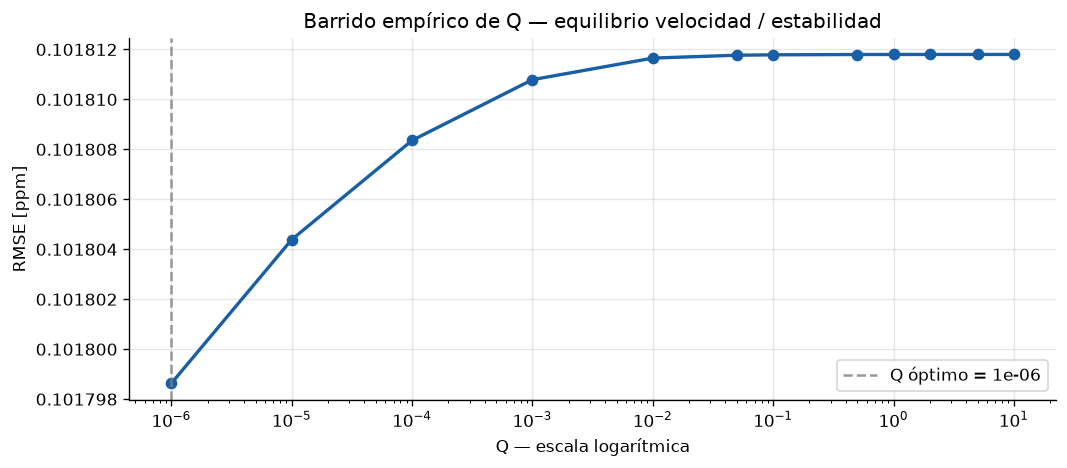

In [17]:
C_target = np.full(len(Rk), UKF_CFG['C0'])

Q_candidatos = [1e-6, 1e-5, 1e-4, 1e-3, 0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
rmse_Q = []

for Q_test in Q_candidatos:
    C_tmp, _ = correr_ukf(Rk, Tk, RHk, Q_test, N, UKF_CFG, PARAMS)
    rmse_Q.append(rmse(C_tmp, C_target))
    print(f"Q = {Q_test:8.5f}  →  RMSE = {rmse_Q[-1]:.4f} ppm")

Q = Q_candidatos[int(np.argmin(rmse_Q))]
print(f"\nQ óptimo seleccionado: {Q}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogx(Q_candidatos, rmse_Q, 'o-', color='#185FA5', linewidth=2)
ax.axvline(Q, color='gray', linestyle='--', alpha=0.8, label=f'Q óptimo = {Q}')
ax.set_xlabel('Q — escala logarítmica')
ax.set_ylabel('RMSE [ppm]')
ax.set_title('Barrido empírico de Q — equilibrio velocidad / estabilidad')
ax.legend()
plt.tight_layout()
plt.show()

## 10. UKF 1D — ejecución sobre la captura completa

RMSE despeje analítico : 0.1018 ppm
RMSE UKF               : 0.1018 ppm


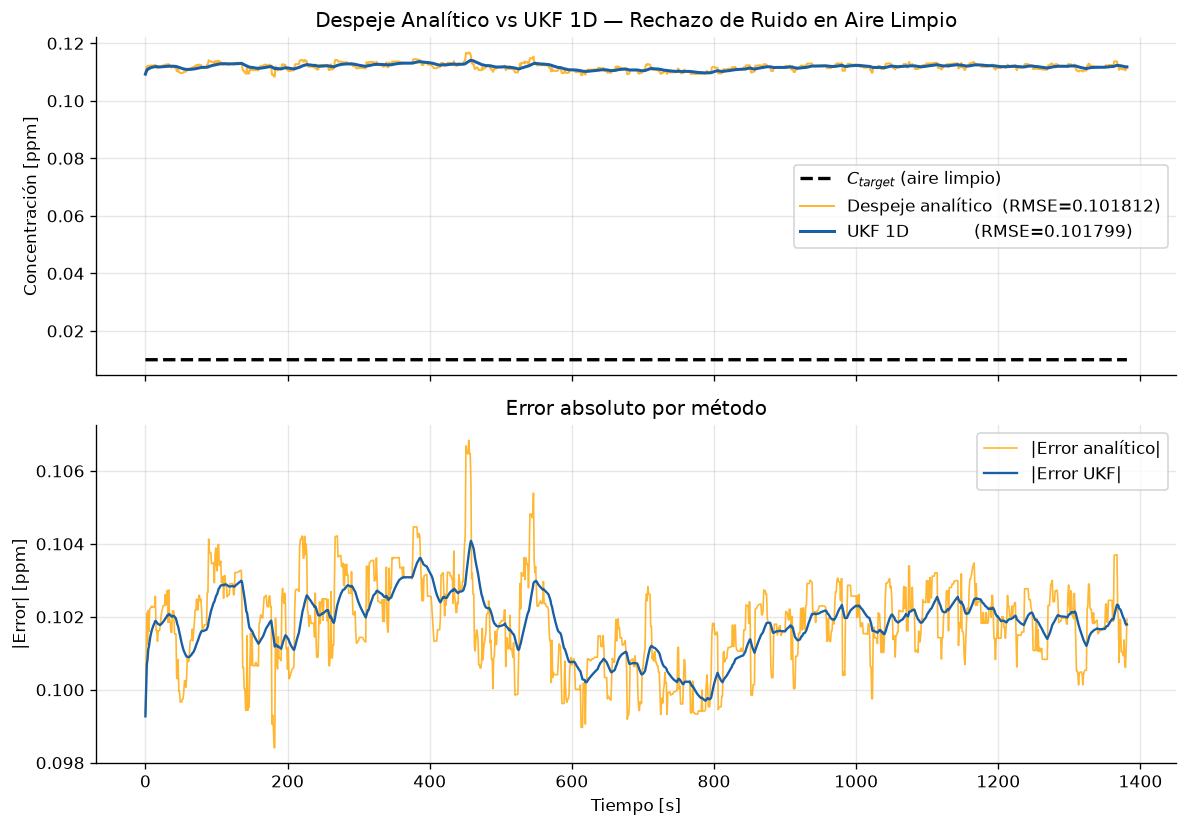

In [19]:
C_ukf, y_tilde = correr_ukf(Rk, Tk, RHk, Q, N, UKF_CFG, PARAMS)

rmse_raw = rmse(C_raw, C_target)
rmse_ukf = rmse(C_ukf, C_target)
print(f"RMSE despeje analítico : {rmse_raw:.4f} ppm")
print(f"RMSE UKF               : {rmse_ukf:.4f} ppm")

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

axes[0].plot(t, C_target, color='black',   linewidth=2,   linestyle='--', label='$C_{target}$ (aire limpio)')
axes[0].plot(t, C_raw,    color='orange',  linewidth=1.2, alpha=0.8,      label=f'Despeje analítico  (RMSE={rmse_raw:.6f})')
axes[0].plot(t, C_ukf,    color='#185FA5', linewidth=1.8,                  label=f'UKF 1D             (RMSE={rmse_ukf:.6f})')
axes[0].set_ylabel('Concentración [ppm]')
axes[0].set_title('Despeje Analítico vs UKF 1D — Rechazo de Ruido en Aire Limpio')
axes[0].legend()

axes[1].plot(t, np.abs(C_raw - C_target), color='orange',  linewidth=1.0, alpha=0.8, label='|Error analítico|')
axes[1].plot(t, np.abs(C_ukf - C_target), color='#185FA5', linewidth=1.4,             label='|Error UKF|')
axes[1].set_ylabel('|Error| [ppm]')
axes[1].set_xlabel('Tiempo [s]')
axes[1].set_title('Error absoluto por método')
axes[1].legend()

plt.tight_layout()
plt.show()

## 11. Regresión Polinomial sobre UKF

RMSE UKF + PoliReg : 0.0000 ppm
R²   UKF + PoliReg : 0.0000   (bajo es esperable — ver nota de la sección 3.7)

Coeficientes del modelo (exportables al firmware):
  w0 (bias) = 0.010000
  C_ukf        = 0.000000
  T            = -0.000000
  RH           = 0.000000
  C_ukf^2      = 0.000000
  C_ukf T      = 0.000000
  C_ukf RH     = -0.000000
  T^2          = 0.000000
  T RH         = -0.000000
  RH^2         = 0.000000


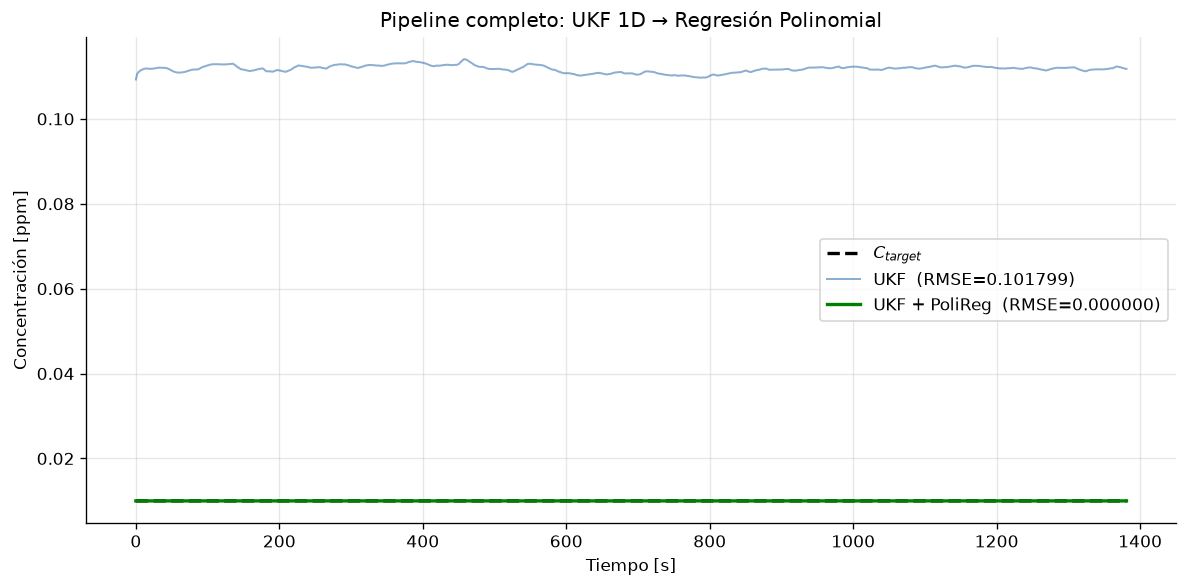

In [21]:
C_ukf_poly, modelo_ukf, poly_ukf = ajustar_polireg(C_ukf, Tk - KELVIN_OFFSET, RHk, C_target)

rmse_ukf_poly = rmse(C_ukf_poly, C_target)
r2_ukf_poly   = r2_score(C_target, C_ukf_poly)
print(f"RMSE UKF + PoliReg : {rmse_ukf_poly:.4f} ppm")
print(f"R²   UKF + PoliReg : {r2_ukf_poly:.4f}   (bajo es esperable — ver nota de la sección 3.7)")

print("\nCoeficientes del modelo (exportables al firmware):")
print(f"  w0 (bias) = {modelo_ukf.intercept_:.6f}")
for nombre, coef in zip(poly_ukf.get_feature_names_out(['C_ukf','T','RH']), modelo_ukf.coef_):
    print(f"  {nombre:12s} = {coef:.6f}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(t, C_target,   color='black',   linewidth=2,   linestyle='--', label='$C_{target}$')
ax.plot(t, C_ukf,      color='#185FA5', linewidth=1.2, alpha=0.5,      label=f'UKF  (RMSE={rmse_ukf:.6f})')
ax.plot(t, C_ukf_poly, color='green',   linewidth=2.0,                  label=f'UKF + PoliReg  (RMSE={rmse_ukf_poly:.6f})')
ax.set_ylabel('Concentración [ppm]')
ax.set_xlabel('Tiempo [s]')
ax.set_title('Pipeline completo: UKF 1D → Regresión Polinomial')
ax.legend()
plt.tight_layout()
plt.show()

## 12. Experimento de control — PoliReg sin UKF

Misma regresión alimentada directamente con `C_raw`, sin pasar por el UKF. Aísla si la mejora viene de la combinación o solo de la regresión.

RMSE PoliReg sin UKF : 0.0000 ppm
R²   PoliReg sin UKF : 0.0000


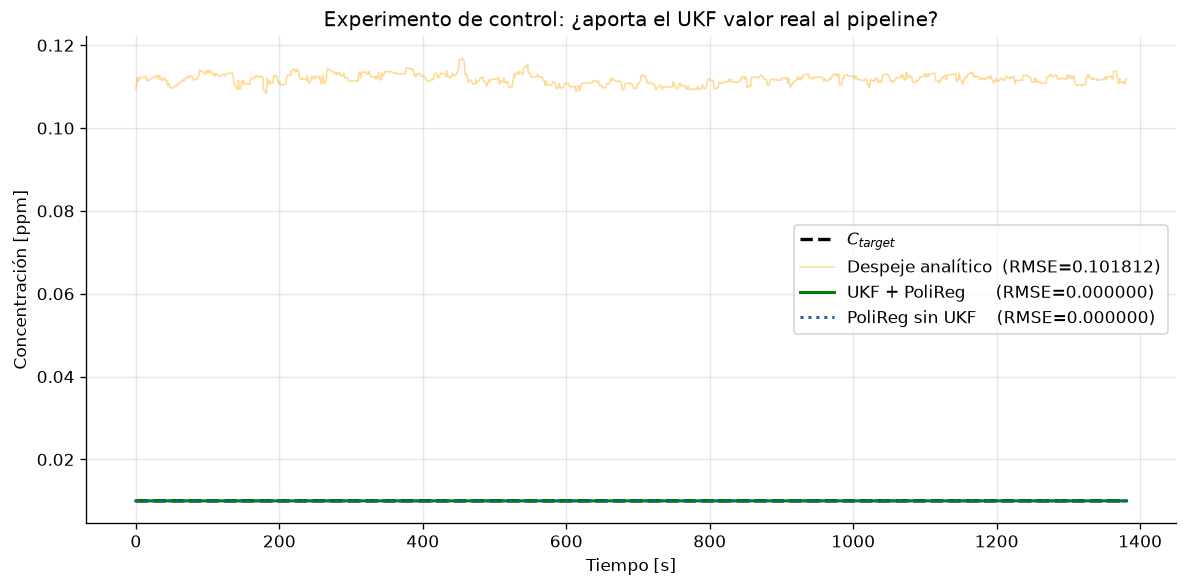

In [23]:
C_raw_poly, modelo_raw, poly_raw = ajustar_polireg(C_raw, Tk - KELVIN_OFFSET, RHk, C_target)

rmse_raw_poly = rmse(C_raw_poly, C_target)
r2_raw_poly   = r2_score(C_target, C_raw_poly)
print(f"RMSE PoliReg sin UKF : {rmse_raw_poly:.4f} ppm")
print(f"R²   PoliReg sin UKF : {r2_raw_poly:.4f}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(t, C_target,   color='black',   linewidth=2,   linestyle='--', label='$C_{target}$')
ax.plot(t, C_raw,      color='orange',  linewidth=1.0, alpha=0.4,      label=f'Despeje analítico  (RMSE={rmse_raw:.6f})')
ax.plot(t, C_ukf_poly, color='green',   linewidth=1.8,                  label=f'UKF + PoliReg      (RMSE={rmse_ukf_poly:.6f})')
ax.plot(t, C_raw_poly, color='#185FA5', linewidth=1.8, linestyle=':',   label=f'PoliReg sin UKF    (RMSE={rmse_raw_poly:.6f})')
ax.set_ylabel('Concentración [ppm]')
ax.set_xlabel('Tiempo [s]')
ax.set_title('Experimento de control: ¿aporta el UKF valor real al pipeline?')
ax.legend()
plt.tight_layout()
plt.show()

## 13. Métricas finales y diagnóstico estocástico

Método                                 RMSE [ppm]     MAE [ppm]        R²
---------------------------------------------------------------------------
Despeje analítico (C_raw)            0.101812  0.101805  -3444580274017339594178542987902976.000000
Solo UKF (C_ukf)                     0.101799  0.101795  -3443685053758392246676948273594368.000000
UKF + PoliReg                        0.000000  0.000000  0.000000
PoliReg sin UKF (control)            0.000000  0.000000  0.000000

───────────────────────────────────────────────────────────────────────────
Diagnóstico UKF — Secuencia de innovación y_tilde:
  Media    = -0.000900   (debe tender a 0 si el filtro es óptimo)
  Varianza = 0.001051
  σ        = 0.032417


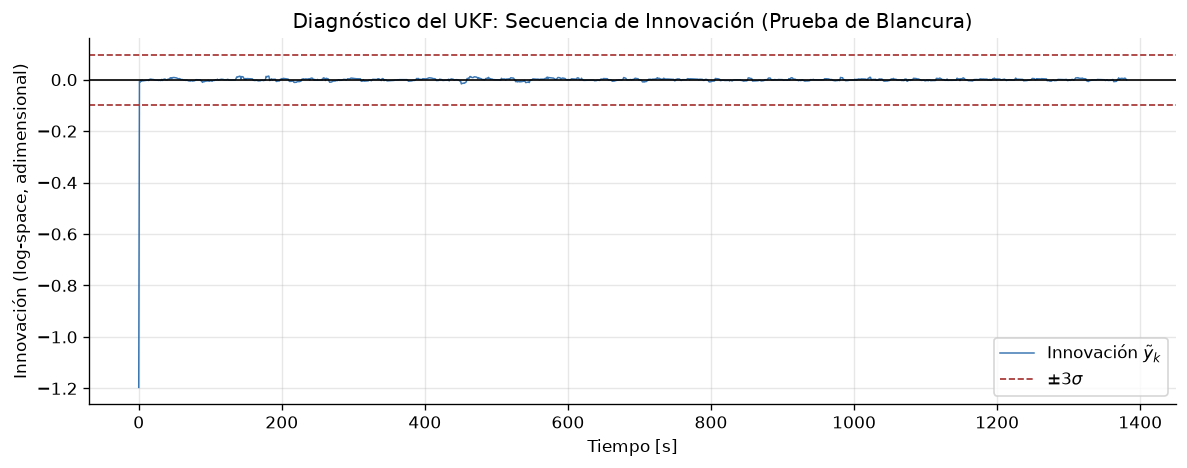

In [27]:
resultados = {
    'Despeje analítico (C_raw)':   C_raw,
    'Solo UKF (C_ukf)':            C_ukf,
    'UKF + PoliReg':               C_ukf_poly,
    'PoliReg sin UKF (control)':   C_raw_poly,
}
tabla_metricas(resultados, C_target)

# ── Diagnóstico de blancura (Whiteness Test) ──────────────────────────────────
media_y = np.mean(y_tilde)
sigma_y = np.std(y_tilde)

print(f"\n{'─'*75}")
print("Diagnóstico UKF — Secuencia de innovación y_tilde:")
print(f"  Media    = {media_y:.6f}   (debe tender a 0 si el filtro es óptimo)")
print(f"  Varianza = {np.var(y_tilde):.6f}")
print(f"  σ        = {sigma_y:.6f}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t, y_tilde, color='#185FA5', linewidth=0.9, alpha=0.85, label=r'Innovación $\tilde{y}_k$')
ax.axhline(0,           color='black',   linewidth=1.0, linestyle='-')
ax.axhline( 3*sigma_y,  color='#A32D2D', linewidth=1.0, linestyle='--', label=r'$\pm 3\sigma$')
ax.axhline(-3*sigma_y,  color='#A32D2D', linewidth=1.0, linestyle='--')
ax.set_ylabel('Innovación (log-space, adimensional)')
ax.set_xlabel('Tiempo [s]')
ax.set_title('Diagnóstico del UKF: Secuencia de Innovación (Prueba de Blancura)')
ax.legend()
plt.tight_layout()
plt.show()

## 14. Trabajo futuro — PoliReg como función de medición aumentada

Idea pendiente de exploración: en vez de aplicar la PoliReg únicamente como post-proceso
sobre la salida del UKF, incorporarla dentro de `h(C, T, RH)` como una corrección aditiva
aprendida sobre el modelo fenomenológico puro.

**El desafío de diseño real:** entrenar esa corrección requiere `C_ukf` como insumo, pero
`C_ukf` depende de `h()` — que es justamente lo que se quiere corregir. Esto es un problema
de bootstrapping, no un simple ajuste de código, y requiere una de estas estrategias:

1. **Entrenamiento iterativo:** correr el UKF con `h()` puro, entrenar la corrección sobre
   el residuo, reinyectarla en `h()`, y repetir hasta convergencia.
2. **Entrenamiento offline con gas de referencia:** usar una captura con concentración
   conocida (no aire limpio) para ajustar la corrección directamente contra `C_true`,
   evitando la dependencia circular.

La segunda opción es la más robusta y es coherente con la metodología de calibración en
laboratorio que exige el marco teórico (sección 2.1) — pero requiere exactamente el tipo de
captura con gas real que esta sesión de aire limpio no puede proveer.